In [ ]:
from google.colab import files
files.upload()

Saving weather_forecast_data.csv to weather_forecast_data.csv


{'weather_forecast_data.csv': b'Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain\r\n23.720337598183118,89.59264065174611,7.335604391040214,50.501693832913155,1032.378758690279,rain\r\n27.879734159310487,46.48970403534824,5.952483593282764,4.990052927536981,992.6141895121403,no rain\r\n25.069084401791095,83.07284289257146,1.3719918180799207,14.855783939243427,1007.2316201172738,no rain\r\n23.622079574922424,74.36775792086564,7.050550632784658,67.25528206034686,982.6320127095369,rain\r\n20.591369983472617,96.85882241307947,4.6439209259534975,47.67644427890656,980.8251417426507,no rain\r\n26.147352826666403,48.21726041042326,15.258546760433369,59.76627863227763,1049.738751014439,no rain\r\n20.939680281567313,40.79944443606025,2.2325659971252265,45.827508421021676,1014.1737660638806,no rain\r\n32.29432501955199,51.848471069719,2.873620839084101,92.5514972525134,1006.0417334780344,no rain\r\n34.09156901252573,48.05711447385431,5.570206017562278,82.52487276907972,993.7320466194785,n

In [ ]:
import pandas as pd
df = pd.read_csv("weather_forecast_data.csv")
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [ ]:
df.shape

(2500, 6)

In [ ]:
scale_column = ["Temperature","Humidity","Wind_Speed","Cloud_Cover","Pressure"]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for scale in scale_column:
    df[scale] = scaler.fit_transform(df[[scale]])
df

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,0.548885,0.851343,0.366485,0.504954,0.748370,rain
1,0.715305,0.235520,0.297292,0.049759,0.180070,no rain
2,0.602850,0.758193,0.068145,0.148433,0.388977,no rain
3,0.544954,0.633821,0.352225,0.672518,0.037409,rain
4,0.423693,0.955157,0.231829,0.476696,0.011586,no rain
...,...,...,...,...,...,...
2495,0.471715,0.218107,0.590184,0.550391,0.538389,no rain
2496,0.702452,0.235407,0.544045,0.397069,0.408404,no rain
2497,0.724449,0.197337,0.144443,0.758410,0.273037,no rain
2498,0.191548,0.398658,0.118308,0.023641,0.950212,no rain


In [ ]:
df["Rain"].unique()

array(['rain', 'no rain'], dtype=object)

In [ ]:
df['Rain'] = df['Rain'].map({"rain":1,"no rain":0})

In [ ]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,0.548885,0.851343,0.366485,0.504954,0.748370,1
1,0.715305,0.235520,0.297292,0.049759,0.180070,0
2,0.602850,0.758193,0.068145,0.148433,0.388977,0
3,0.544954,0.633821,0.352225,0.672518,0.037409,1
4,0.423693,0.955157,0.231829,0.476696,0.011586,0


In [ ]:
X = df.drop("Rain",axis=1)
y = df["Rain"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2000, 5)
X_test shape: (500, 5)
y_train shape: (2000,)
y_test shape: (500,)


In [ ]:
y_train.value_counts()

,count
Rain,
0,1743
1,257


In [ ]:
X_train.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
2055,0.000000,0.689312,0.248684,0.298772,0.766420
1961,0.964392,0.040566,0.360035,0.941527,0.685669
1864,0.209585,0.743031,0.534580,0.207024,0.946385
2326,0.286467,0.664045,0.683908,0.559104,0.880115
461,0.379084,0.901632,0.084175,0.522223,0.697655


In [ ]:
y_train.head()

,Rain
2055,0
1961,0
1864,0
2326,1
461,1


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Instantiate RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Resample the training data
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print("Original y_train value counts:")
print(y_train.value_counts())
print("\nResampled y_train value counts:")
print(y_train_resampled.value_counts())

Original y_train value counts:
Rain
0    1743
1     257
Name: count, dtype: int64

Resampled y_train value counts:
Rain
0    257
1    257
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier



In [ ]:
# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model using the resampled training data
dt_classifier.fit(X_train_resampled, y_train_resampled)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [ ]:
y_predics = dt_classifier.predict(X_test)
y_predics

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

In [ ]:
y_test

,Rain
1447,0
1114,0
1064,1
2287,0
1537,0
...,...
2375,0
1609,0
596,1
84,0


In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_predics)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       443
           1       0.95      1.00      0.97        57

    accuracy                           0.99       500
   macro avg       0.97      1.00      0.99       500
weighted avg       0.99      0.99      0.99       500



In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_predics)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[440   3]
 [  0  57]]


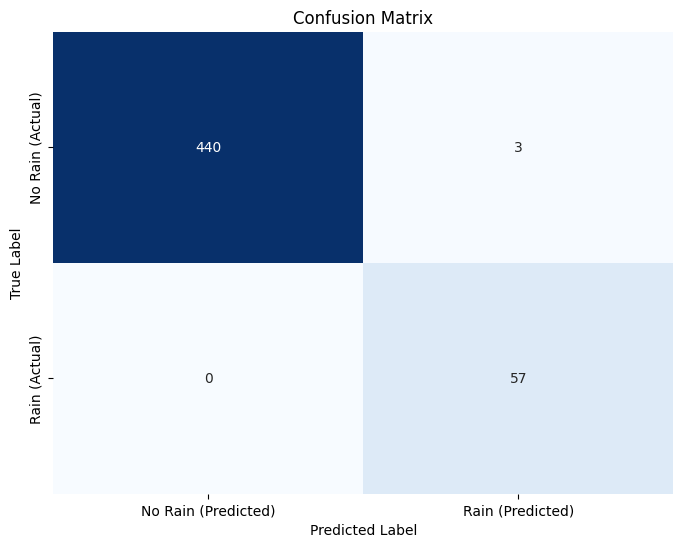

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

***over sampling***

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Instantiate RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Resample the training data
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)

print("Original y_train value counts:")
print(y_train.value_counts())
print("\nOversampled y_train value counts:")
print(y_train_oversampled.value_counts())

Original y_train value counts:
Rain
0    1743
1     257
Name: count, dtype: int64

Oversampled y_train value counts:
Rain
0    1743
1    1743
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Initialize the Decision Tree Classifier
dt_classifier_oversample = DecisionTreeClassifier(random_state=42)

# Train the model using the resampled training data
dt_classifier_oversample.fit(X_train_oversampled, y_train_oversampled)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [ ]:
y_predics_oversample = dt_classifier_oversample.predict(X_test)[:10]
y_predics_oversample

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
y_test[:10]

,Rain
1447,0
1114,0
1064,1
2287,0
1537,0
668,0
1583,0
2404,0
497,0
2480,0


In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_predics_oversample)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       443
           1       1.00      1.00      1.00        57

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the oversampled model
cm_oversample = confusion_matrix(y_test, y_predics_oversample)

print("Confusion Matrix (Oversampled Model):")
print(cm_oversample)

Confusion Matrix (Oversampled Model):
[[443   0]
 [  0  57]]


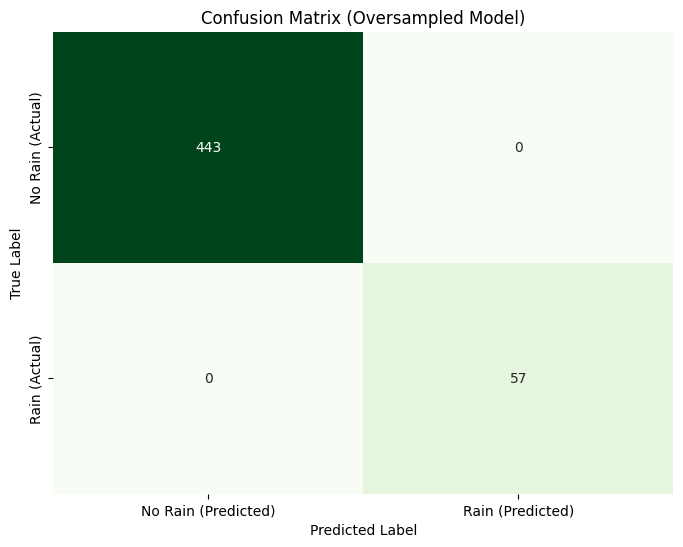

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_oversample, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix (Oversampled Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

***smote***

In [ ]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the training data using SMOTE
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original y_train value counts:")
print(y_train.value_counts())
print("\nSMOTE-resampled y_train value counts:")
print(y_train_smote.value_counts())

Original y_train value counts:
Rain
0    1743
1     257
Name: count, dtype: int64

SMOTE-resampled y_train value counts:
Rain
0    1743
1    1743
Name: count, dtype: int64


In [ ]:
# Initialize a new Decision Tree Classifier for SMOTE data
dt_classifier_smote = DecisionTreeClassifier(random_state=42)

# Train the model using the SMOTE-resampled training data
dt_classifier_smote.fit(X_train_smote, y_train_smote)

print("Decision Tree Classifier trained successfully with SMOTE data!")

Decision Tree Classifier trained successfully with SMOTE data!


In [ ]:
# Make predictions on the original X_test set using the SMOTE-trained model
y_predics_smote = dt_classifier_smote.predict(X_test)

print("Predictions made successfully!")

Predictions made successfully!


In [ ]:
# Display the classification report for the SMOTE-trained model
from sklearn.metrics import classification_report

report_smote = classification_report(y_test, y_predics_smote)
print("Classification Report (SMOTE Model):\n")
print(report_smote)

Classification Report (SMOTE Model):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       443
           1       1.00      1.00      1.00        57

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



Confusion Matrix (SMOTE Model):

[[443   0]
 [  0  57]]


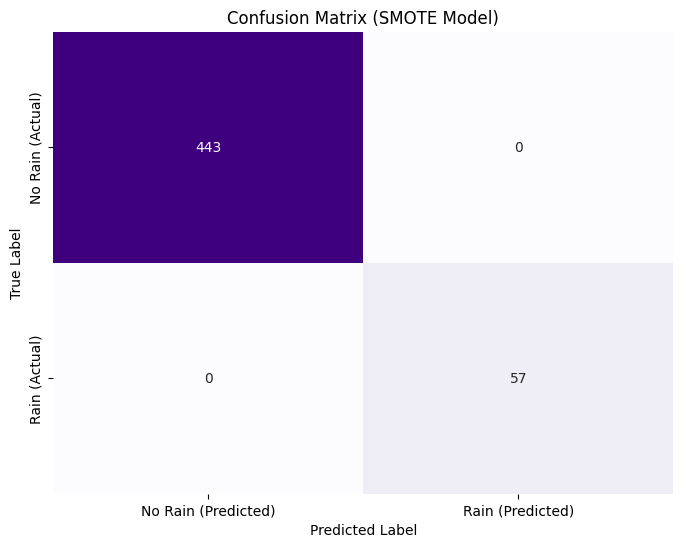

In [ ]:
# Generate and display the confusion matrix for the SMOTE-trained model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_predics_smote)

print("Confusion Matrix (SMOTE Model):\n")
print(cm_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix (SMOTE Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.svm import SVC

# Initialize a new SVM Classifier for SMOTE data
svm_classifier_smote = SVC(random_state=42)

# Train the model using the SMOTE-resampled training data
svm_classifier_smote.fit(X_train_smote, y_train_smote)

print("SVM Classifier trained successfully with SMOTE data!")

SVM Classifier trained successfully with SMOTE data!


In [ ]:
# Make predictions on the original X_test set using the SMOTE-trained SVM model
y_predics_svm_smote = svm_classifier_smote.predict(X_test)

print("Predictions made successfully with SVM!")

Predictions made successfully with SVM!


In [ ]:
from sklearn.metrics import classification_report

# Display the classification report for the SMOTE-trained SVM model
report_svm_smote = classification_report(y_test, y_predics_svm_smote)
print("Classification Report (SMOTE + SVM Model):\n")
print(report_svm_smote)

Classification Report (SMOTE + SVM Model):

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       443
           1       0.79      0.93      0.85        57

    accuracy                           0.96       500
   macro avg       0.89      0.95      0.92       500
weighted avg       0.97      0.96      0.97       500



Confusion Matrix (SMOTE + SVM Model):

[[429  14]
 [  4  53]]


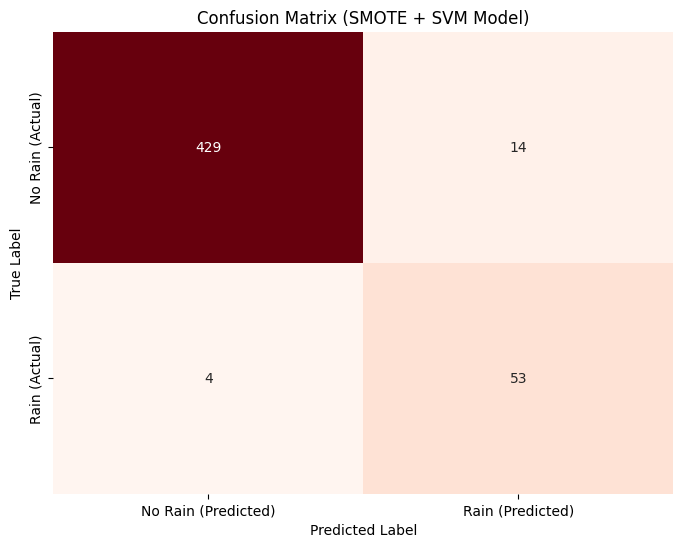

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate and display the confusion matrix for the SMOTE-trained SVM model
cm_svm_smote = confusion_matrix(y_test, y_predics_svm_smote)

print("Confusion Matrix (SMOTE + SVM Model):\n")
print(cm_svm_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_smote, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix (SMOTE + SVM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Initialize GridSearchCV
# We'll use the SMOTE-resampled training data for tuning
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='f1', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_search_svm.fit(X_train_smote, y_train_smote)

print("Grid search completed!")
print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best F1-score (on training data with cross-validation): {grid_search_svm.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid search completed!
Best parameters: {'C': 100, 'kernel': 'rbf'}
Best F1-score (on training data with cross-validation): 0.9881


Classification Report (SMOTE + Tuned SVM Model):

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       443
           1       0.90      0.93      0.91        57

    accuracy                           0.98       500
   macro avg       0.94      0.96      0.95       500
weighted avg       0.98      0.98      0.98       500

Confusion Matrix (SMOTE + Tuned SVM Model):

[[437   6]
 [  4  53]]


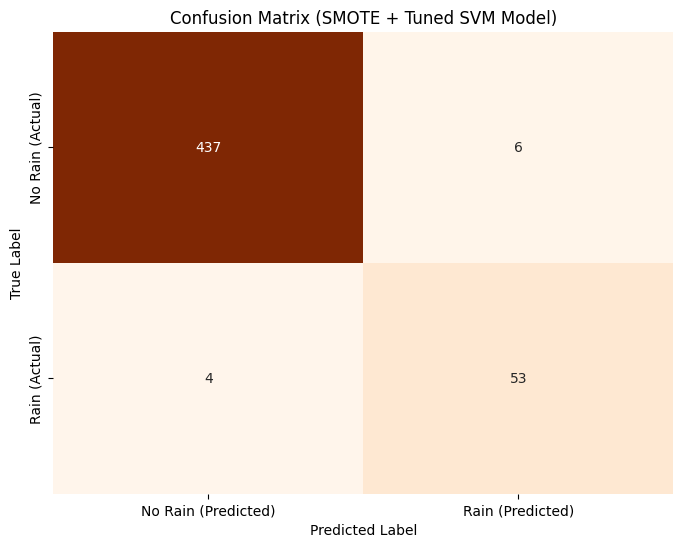

In [ ]:
# Get the best SVM model from the grid search
best_svm_smote = grid_search_svm.best_estimator_

# Make predictions on the original X_test set using the best SMOTE-tuned SVM model
y_predics_best_svm_smote = best_svm_smote.predict(X_test)

# Display the classification report for the best SMOTE-tuned SVM model
report_best_svm_smote = classification_report(y_test, y_predics_best_svm_smote)
print("Classification Report (SMOTE + Tuned SVM Model):\n")
print(report_best_svm_smote)

# Generate and display the confusion matrix for the best SMOTE-tuned SVM model
cm_best_svm_smote = confusion_matrix(y_test, y_predics_best_svm_smote)

print("Confusion Matrix (SMOTE + Tuned SVM Model):\n")
print(cm_best_svm_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svm_smote, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix (SMOTE + Tuned SVM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Random Forest Classifier with SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a Random Forest Classifier
rf_classifier_smote = RandomForestClassifier(random_state=42)

# Train the model using the SMOTE-resampled training data
rf_classifier_smote.fit(X_train_smote, y_train_smote)

print("Random Forest Classifier trained successfully with SMOTE data!")

Random Forest Classifier trained successfully with SMOTE data!


In [ ]:
# Make predictions on the original X_test set using the SMOTE-trained Random Forest model
y_predics_rf_smote = rf_classifier_smote.predict(X_test)

print("Predictions made successfully with Random Forest!")

Predictions made successfully with Random Forest!


Classification Report (SMOTE + Random Forest Model):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       443
           1       1.00      0.98      0.99        57

    accuracy                           1.00       500
   macro avg       1.00      0.99      1.00       500
weighted avg       1.00      1.00      1.00       500

Confusion Matrix (SMOTE + Random Forest Model):

[[443   0]
 [  1  56]]


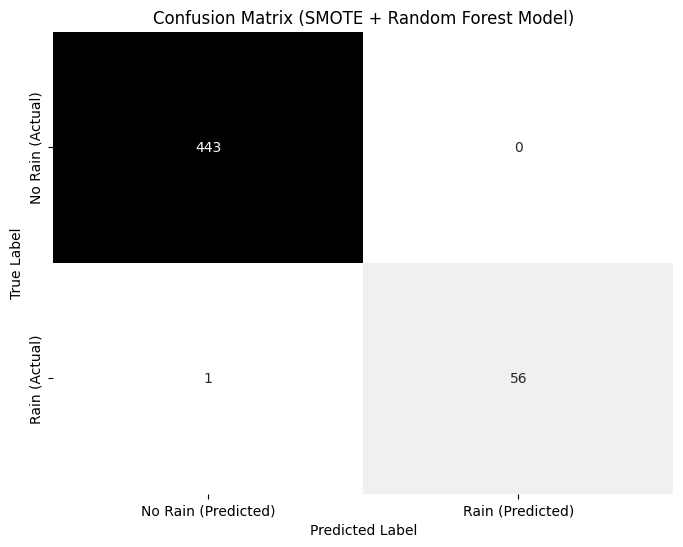

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Display the classification report for the SMOTE-trained Random Forest model
report_rf_smote = classification_report(y_test, y_predics_rf_smote)
print("Classification Report (SMOTE + Random Forest Model):\n")
print(report_rf_smote)

# Generate and display the confusion matrix for the SMOTE-trained Random Forest model
cm_rf_smote = confusion_matrix(y_test, y_predics_rf_smote)

print("Confusion Matrix (SMOTE + Random Forest Model):\n")
print(cm_rf_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=['No Rain (Predicted)', 'Rain (Predicted)'],
            yticklabels=['No Rain (Actual)', 'Rain (Actual)'])
plt.title('Confusion Matrix (SMOTE + Random Forest Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()